## 1. Extract: Load the Raw Data

Loading the raw BankChurners CSV into a pandas DataFrame so we can begin exploring its structure.

In [2]:
import pandas as pd

df = pd.read_csv("C:\\Users\\Hevack\\Churning_Analysis\\data\\raw\\BankChurners.csv")
df.head() #to see the first 5 rows of the DataFrame

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 2. Explore: Structure of the Dataset

Checking the shape, column types, and completeness of the raw data before cleaning.

In [3]:
df.info() #to see the information about the DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                                      

## 3. Explore: Checking for Hidden Missing Values

_.info() showed no NaN values, but categorical columns can contain placeholder text like "Unknown" instead of a true null — checking for these before proceeding._

In [4]:
cat = df.select_dtypes(include='object').columns
for i in cat:
    print(i)
    print(df[i].unique())#to see the unique values in each categorical column

Attrition_Flag
<StringArray>
['Existing Customer', 'Attrited Customer']
Length: 2, dtype: str
Gender
<StringArray>
['M', 'F']
Length: 2, dtype: str
Education_Level
<StringArray>
[  'High School',      'Graduate',    'Uneducated',       'Unknown',
       'College', 'Post-Graduate',     'Doctorate']
Length: 7, dtype: str
Marital_Status
<StringArray>
['Married', 'Single', 'Unknown', 'Divorced']
Length: 4, dtype: str
Income_Category
<StringArray>
[   '$60K - $80K', 'Less than $40K',   '$80K - $120K',    '$40K - $60K',
        '$120K +',        'Unknown']
Length: 6, dtype: str
Card_Category
<StringArray>
['Blue', 'Gold', 'Silver', 'Platinum']
Length: 4, dtype: str


C:\Users\Hevack\AppData\Local\Temp\ipykernel_2780\2338896008.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include='object').columns


## 4. Handling "Unknown" Values:
_Found "Unknown" as a placeholder value in 3 categorical columns: Marital_Status, Income_Category, and Education_Level. Before deciding how to handle these, checking the proportion of "Unknown" values in each column to understand their impact on the dataset._

In [5]:
df['Education_Level'].value_counts() #to see the distribution of education levels

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

In [6]:
df['Marital_Status'].value_counts() #to see the distribution of marital status categories

Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

In [7]:
df['Income_Category'].value_counts() #to see the distribution of income categories

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

**Result**:
 Given the meaningful proportion of "Unknown" in each column, these rows were not dropped. Imputing a guessed value could bias the analysis, so "Unknown" was retained as a valid category, treated the same as any other response._

## 5. Checking for Duplicate Rows

_Checking whether any rows are fully duplicated, which could distort counts and averages in the analysis._

In [8]:
df.duplicated().sum() #to check for duplicate rows in the DataFrame 

np.int64(0)

No fully duplicated rows were found in the dataset, so no rows needed to be removed at this stage.

## 6. Dropping Irrelevant Columns

_The dataset includes two Naive Bayes classifier output columns left over from a prior experiment (not original customer data, per the dataset's documentation). These are dropped as they are not relevant to this analysis._

In [19]:
# Identify the Naive Bayes columns
cols_to_drop = [col for col in df.columns if 'Naive_Bayes' in col]

# Drop them from the DataFrame
df = df.drop(columns=cols_to_drop)

df     #to see the DataFrame after dropping the Naive Bayes columns

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


## 7. Cleaning Column Names

_Inspecting column names for any leading or trailing whitespace, which can silently cause KeyErrors when selecting or dropping columns, and stripping it to ensure column names are clean and consistent._

In [22]:
# Inspect column names
print(df.columns)

df.columns = df.columns.str.strip() #strip any leading or trailing whitespace from column names


Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='str')


## 8. Confirming Data Types

_Checking each column's data type to confirm numeric fields are stored as numbers and categorical fields as text, ensuring nothing was misread during the initial load._

In [23]:
df.dtypes

CLIENTNUM                     int64
Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

## 9.Statistical Summary of Numeric Columns

_Reviewing the min, max, mean, and quartiles of each numeric column to spot any impossible or unusual values (e.g. negative ages, zero credit limits) before finalising the cleaned dataset._

In [24]:
df.describe() #to see the general numerical statistics of the DataFrame

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


## 10. Load: Save the Cleaned Dataset

_Saving the cleaned DataFrame to data/cleaned/ as a checkpoint, so the analysis phase can start from this file._

In [29]:
df.to_csv("C:\\Users\\Hevack\\Churning_Analysis\\data\\cleaned\\BankChurners_cleaned.csv", index=False) #to save the cleaned DataFrame to a new CSV file

## 10. Univariate Overview: Numeric Columns

_Before diving into churn-specific analysis, plotting histograms for every numeric column to get a general sense of each variable's distribution — checking for skew, spread, and anything unusual._

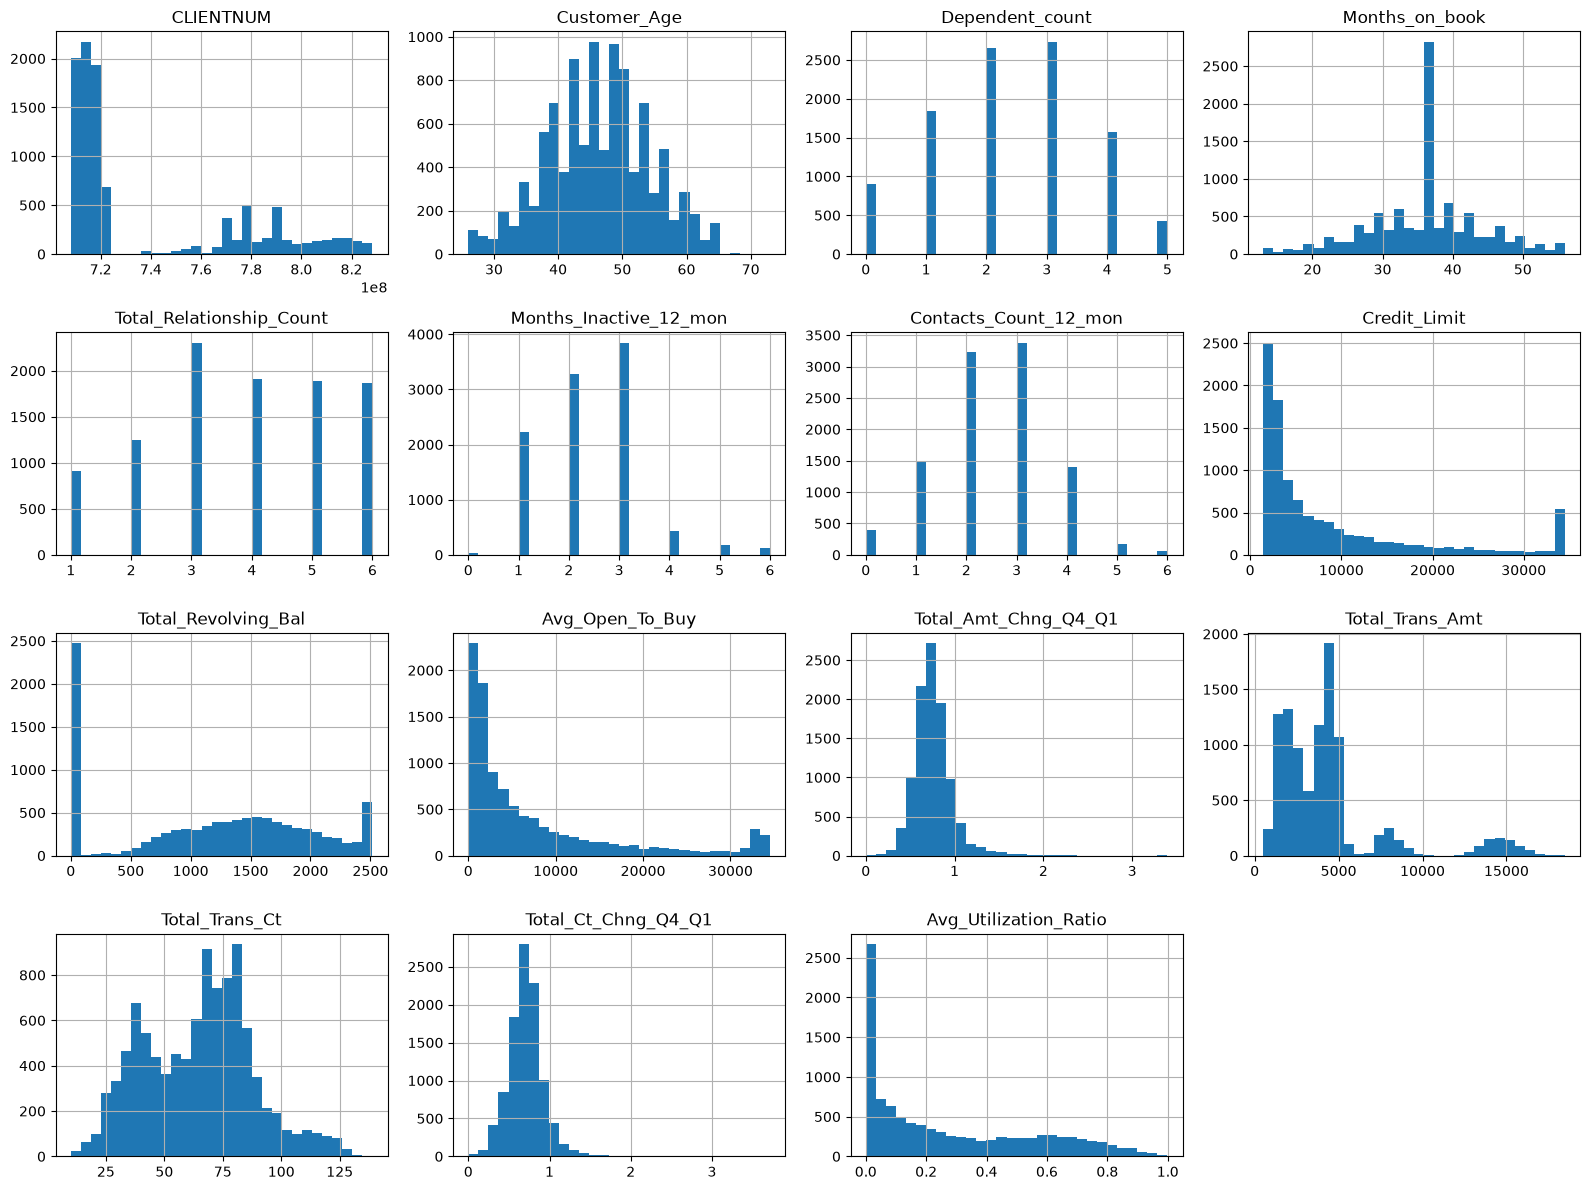

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

df.select_dtypes(include='number').hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show() # Display the histogram

**Observations:**
- 
- *_Credit_Limit_* is heavily right-skewed, with most customers holding lower limits and a small cluster at the maximum (~$34,500), suggesting a possible cap in the data.

- _Total_Revolving_Bal_ shows two distinct customer behaviours: a large spike at $0 (customers who carry no balance) alongside a separate cluster around $2,500.

- _Total_Trans_Ct_ and _Total_Trans_Amt_ are both bimodal, suggesting two underlying groups of customer transaction behaviour, worth investigating against churn status later.

- _Months_on_book_ shows an unusual spike at exactly 36 months, likely a default or placeholder value rather than a true customer tenure.

- _Total_Amt_Chng_Q4_Q1_ is a spending-change ratio: values near 1 indicate stable spending, values above 1 indicate increased spending, and values near 0 indicate a sharp spending drop — a strong candidate to compare against churn later.

- _CLIENTNUM_ is a unique identifier and not analytically meaningful — excluded from interpretation.
